In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [2]:
products = [p for p in prices['product'].unique() if str(p).startswith("PANEL")]

In [3]:
prices = prices[prices["product"].isin(products)].copy()

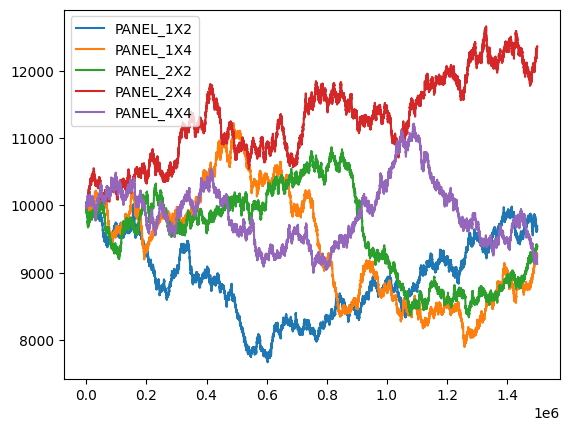

In [4]:
for p in products:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [5]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

pairs: 100%|██████████| 25/25 [01:08<00:00,  2.72s/it]


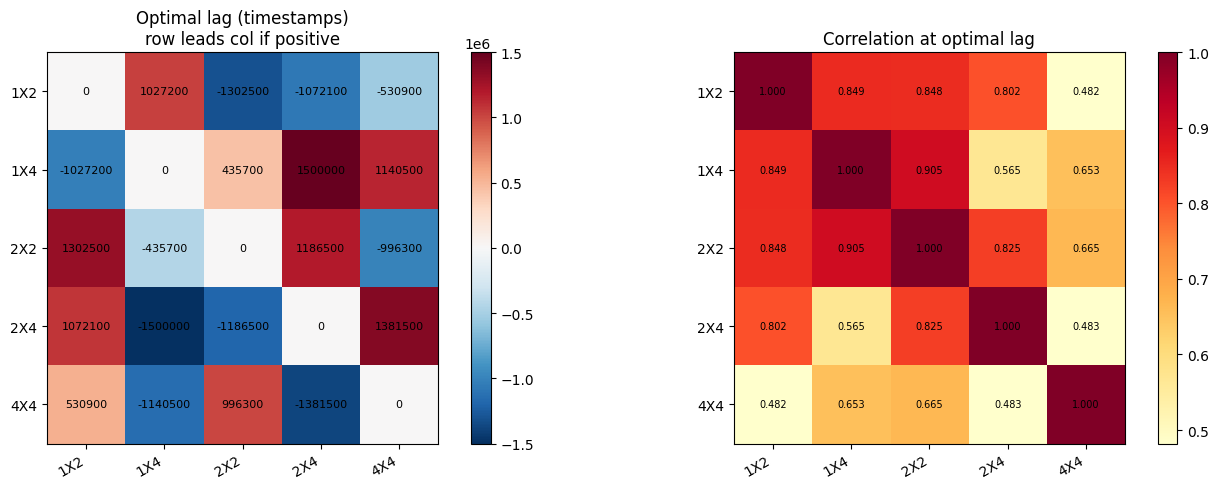

Timestamp step: 100 | Searching +/-1500000 ts = +/-15000 array shifts per pair

Pairwise optimal lead-lag summary (row LEADS col by N timestamps):
  1X2 vs 1X4: lag=+1027200 ts  corr=0.8490  -> 1X2 leads 1X4 by 1027200 ts
  1X2 vs 2X2: lag=-1302500 ts  corr=0.8478  -> 2X2 leads 1X2 by 1302500 ts
  1X2 vs 2X4: lag=-1072100 ts  corr=0.8024  -> 2X4 leads 1X2 by 1072100 ts
  1X2 vs 4X4: lag=-530900 ts  corr=0.4821  -> 4X4 leads 1X2 by 530900 ts
  1X4 vs 2X2: lag=+435700 ts  corr=0.9048  -> 1X4 leads 2X2 by 435700 ts
  1X4 vs 2X4: lag=+1500000 ts  corr=0.5653  -> 1X4 leads 2X4 by 1500000 ts
  1X4 vs 4X4: lag=+1140500 ts  corr=0.6527  -> 1X4 leads 4X4 by 1140500 ts
  2X2 vs 2X4: lag=+1186500 ts  corr=0.8255  -> 2X2 leads 2X4 by 1186500 ts
  2X2 vs 4X4: lag=-996300 ts  corr=0.6654  -> 4X4 leads 2X2 by 996300 ts
  2X4 vs 4X4: lag=+1381500 ts  corr=0.4832  -> 2X4 leads 4X4 by 1381500 ts


In [7]:
from tqdm.auto import tqdm

# Pairwise optimal lead-lag analysis
# For each pair (A, B), find the lag L that maximizes corr(A[t], B[t+L])
# Positive L means A leads B (B lags behind A)

MAX_LAG_TS = 1_500_000  # max lag in timestamp units

sleep_cols = [c for c in mids.columns if c.startswith("PANEL")]
filled = mids[sleep_cols].ffill()

ts_step = int(filled.index[1] - filled.index[0])   # 100: one array shift = 100 ts units
max_lag_idx = MAX_LAG_TS // ts_step                 # number of array positions to sweep

lag_idxs = np.arange(-max_lag_idx, max_lag_idx + 1)
n = len(sleep_cols)
opt_lag = np.zeros((n, n), dtype=int)
opt_corr = np.zeros((n, n))

pairs = [(i, a, j, b) for i, a in enumerate(sleep_cols) for j, b in enumerate(sleep_cols)]
for i, a, j, b in tqdm(pairs, desc="pairs"):
    if i == j:
        opt_lag[i, j] = 0
        opt_corr[i, j] = 1.0
        continue
    sa = filled[a].values
    sb = filled[b].values
    xcorr = np.array([
        np.corrcoef(sa[:len(sa)-abs(l)], sb[abs(l):])[0, 1] if l >= 0
        else np.corrcoef(sa[abs(l):], sb[:len(sb)-abs(l)])[0, 1]
        for l in lag_idxs
    ])
    best = np.argmax(xcorr)
    opt_lag[i, j] = lag_idxs[best] * ts_step   # report in timestamp units
    opt_corr[i, j] = xcorr[best]

short_names = [c.replace("PANEL_", "") for c in sleep_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(opt_lag, cmap="RdBu_r", vmin=-MAX_LAG_TS, vmax=MAX_LAG_TS)
axes[0].set_title("Optimal lag (timestamps)\nrow leads col if positive")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, opt_lag[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im0, ax=axes[0])

# Use actual data min so the full range of variation is visible
corr_min = opt_corr.min()
im1 = axes[1].imshow(opt_corr, cmap="YlOrRd", vmin=corr_min, vmax=1.0)
axes[1].set_title("Correlation at optimal lag")
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{opt_corr[i, j]:.3f}", ha="center", va="center", fontsize=7)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Timestamp step: {ts_step} | Searching +/-{MAX_LAG_TS} ts = +/-{max_lag_idx} array shifts per pair")
print("\nPairwise optimal lead-lag summary (row LEADS col by N timestamps):")
for i, a in enumerate(short_names):
    for j, b in enumerate(short_names):
        if i < j:
            lag = opt_lag[i, j]
            direction = f"{a} leads {b}" if lag > 0 else f"{b} leads {a}" if lag < 0 else "no lead"
            print(f"  {a} vs {b}: lag={lag:+d} ts  corr={opt_corr[i,j]:.4f}  -> {direction} by {abs(lag)} ts")